# UniTalk-ASD — Dataset Exploration

Class balance, track/temporal statistics, bounding-box stats, and a look at the raw CSV rows and face-crop images, over the downloaded `data/raw/` split.

## 1. Setup & Imports

### Imports, paths and plot style

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from config import RAW_CSV_DIR, RAW_CLIPS_VIDEOS_DIR, SPLITS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


### Load train and val CSVs

In [3]:
train_df = pd.read_csv(RAW_CSV_DIR / "train_orig.csv")
val_df   = pd.read_csv(RAW_CSV_DIR / "val_orig.csv")

dfs = {"train": train_df, "val": val_df}

for split, df in dfs.items():
    print(f"{split}: {len(df):,} rows")


train: 3,001,883 rows
val: 998,644 rows


## 2. Dataset Overview

### Schema and dtypes

In [4]:
train_df.dtypes.to_frame("dtype")

,dtype
video_id,str
frame_timestamp,float64
entity_box_x1,float64
entity_box_y1,float64
entity_box_x2,float64
entity_box_y2,float64
label,str
entity_id,str
label_id,int64
instance_id,str


### First rows

In [5]:
train_df.head(10)

,video_id,frame_timestamp,entity_box_x1,entity_box_y1,entity_box_x2,entity_box_y2,label,entity_id,label_id,instance_id
0,-ASZexdSdWE,0.16,0.923705,0.331340,0.979650,0.459454,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
1,-ASZexdSdWE,0.20,0.923952,0.328611,0.980176,0.461758,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
2,-ASZexdSdWE,0.24,0.923125,0.329036,0.980767,0.461767,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
3,-ASZexdSdWE,0.28,0.922738,0.332406,0.980203,0.463286,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
4,-ASZexdSdWE,0.32,0.923400,0.334192,0.979988,0.463199,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
5,-ASZexdSdWE,0.36,0.923646,0.334681,0.980114,0.463327,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
6,-ASZexdSdWE,0.40,0.923819,0.334628,0.979975,0.463113,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
7,-ASZexdSdWE,0.44,0.923972,0.335117,0.979997,0.463623,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
8,-ASZexdSdWE,0.48,0.923109,0.335312,0.979166,0.462377,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0
9,-ASZexdSdWE,0.52,0.922121,0.335033,0.978581,0.464846,NOT_SPEAKING,-ASZexdSdWE:0,0,-ASZexdSdWE:0:0


### Missing values per column

In [6]:
missing = pd.DataFrame({split: df.isna().sum() for split, df in dfs.items()})
missing


,train,val
video_id,0,0
frame_timestamp,0,0
entity_box_x1,0,0
entity_box_y1,0,0
entity_box_x2,0,0
entity_box_y2,0,0
label,0,0
entity_id,0,0
label_id,0,0
instance_id,0,0


### High-level counts (videos, tracks, rows) per split

In [7]:
overview = pd.DataFrame({
    split: {
        "rows": len(df),
        "videos": df["video_id"].nunique(),
        "tracks (entity_id)": df["entity_id"].nunique(),
    }
    for split, df in dfs.items()
}).T
overview


,rows,videos,tracks (entity_id)
train,3001883,95,36791
val,998644,22,11902


## 3. Class Balance

### `label` / `label_id` mapping sanity check

In [8]:
for split, df in dfs.items():
    print(f"--- {split} ---")
    print(df.groupby(["label_id", "label"]).size(), end="\n\n")


--- train ---
label_id  label           
0         NOT_SPEAKING        2160075
1         SPEAKING_AUDIBLE     841808
dtype: int64

--- val ---
label_id  label           
0         NOT_SPEAKING        792938
1         SPEAKING_AUDIBLE    205706
dtype: int64



### Resolve the `label_id` that means SPEAKING_AUDIBLE

In [9]:
SPEAKING_LABEL_ID = train_df.loc[train_df["label"] == "SPEAKING_AUDIBLE", "label_id"].iloc[0]
print(f"SPEAKING_AUDIBLE -> label_id {SPEAKING_LABEL_ID}")


SPEAKING_AUDIBLE -> label_id 1


### Frame-level class balance, train vs val

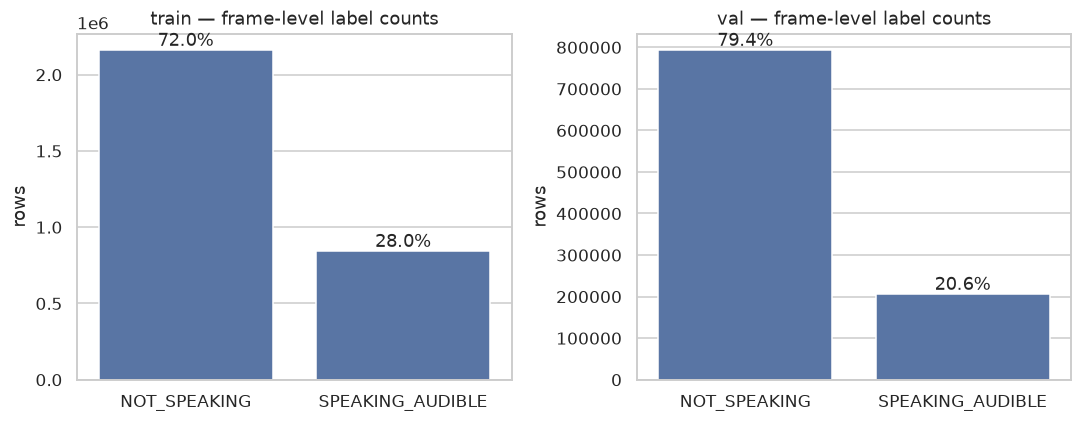

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split, df) in zip(axes, dfs.items()):
    counts = df["label"].value_counts()
    pct = counts / counts.sum() * 100
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    for i, (c, p) in enumerate(zip(counts.values, pct.values)):
        ax.text(i, c, f"{p:.1f}%", ha="center", va="bottom")
    ax.set_title(f"{split} — frame-level label counts")
    ax.set_ylabel("rows")
    ax.set_xlabel("")
fig.tight_layout()
plt.show()


### Track-level class balance (speaking fraction per track)

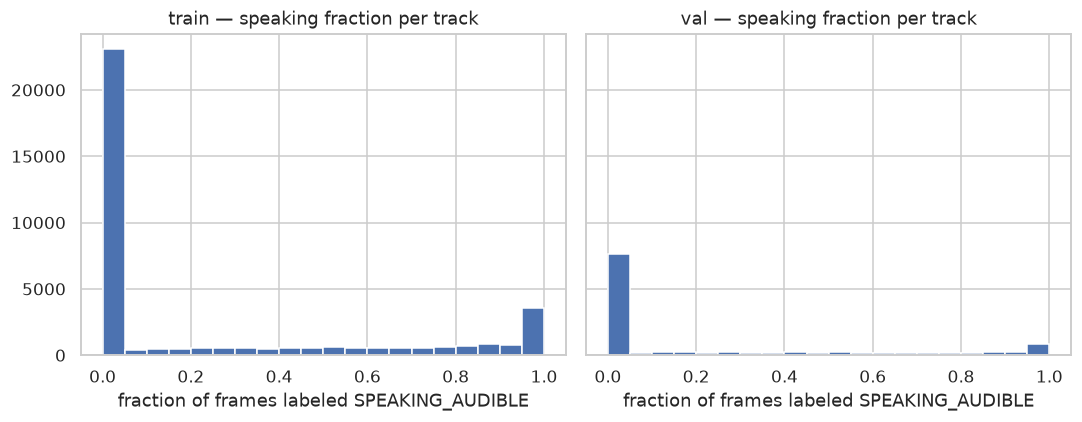

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (split, df) in zip(axes, dfs.items()):
    speaking_frac = df.groupby("entity_id")["label_id"].apply(lambda s: (s == SPEAKING_LABEL_ID).mean())
    ax.hist(speaking_frac, bins=20)
    ax.set_title(f"{split} — speaking fraction per track")
    ax.set_xlabel("fraction of frames labeled SPEAKING_AUDIBLE")
fig.tight_layout()
plt.show()


## 4. Track-Level & Temporal Statistics

### Track length distribution (frames per track)

train:
count    36791.000000
mean        81.592862
std         98.559556
min          1.000000
25%         37.000000
50%         55.000000
75%         89.000000
max       3525.000000
dtype: float64

val:
count    11902.000000
mean        83.905562
std        157.317335
min          3.000000
25%         35.000000
50%         52.000000
75%         83.000000
max       3310.000000
dtype: float64



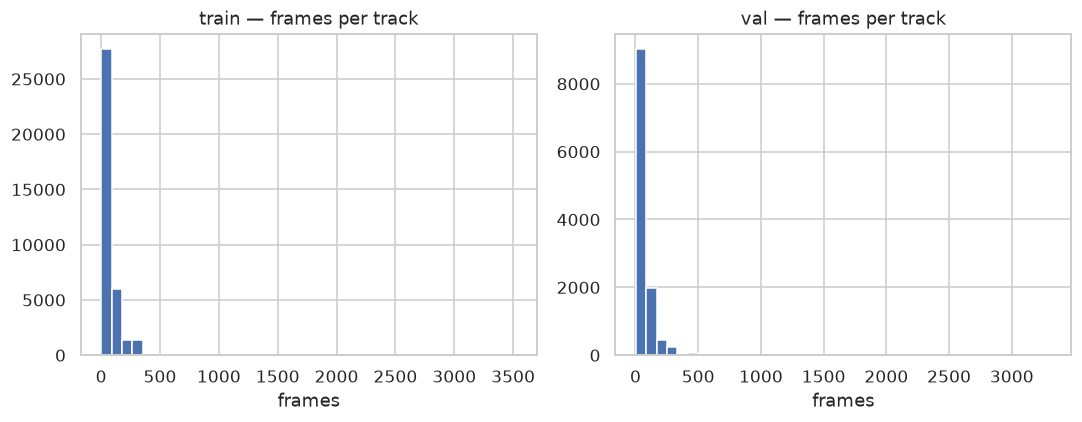

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split, df) in zip(axes, dfs.items()):
    track_len = df.groupby("entity_id").size()
    ax.hist(track_len, bins=40)
    ax.set_title(f"{split} — frames per track")
    ax.set_xlabel("frames")
    print(f"{split}:\n{track_len.describe()}\n")
fig.tight_layout()
plt.show()


### Track duration in seconds

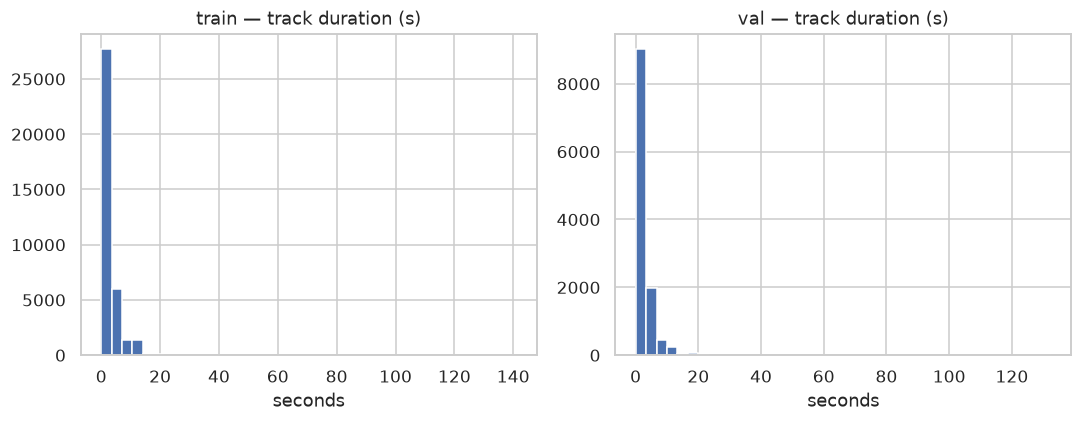

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split, df) in zip(axes, dfs.items()):
    duration = df.groupby("entity_id")["frame_timestamp"].agg(lambda s: s.max() - s.min())
    ax.hist(duration, bins=40)
    ax.set_title(f"{split} — track duration (s)")
    ax.set_xlabel("seconds")
fig.tight_layout()
plt.show()


### Frame sampling interval (consistency check)

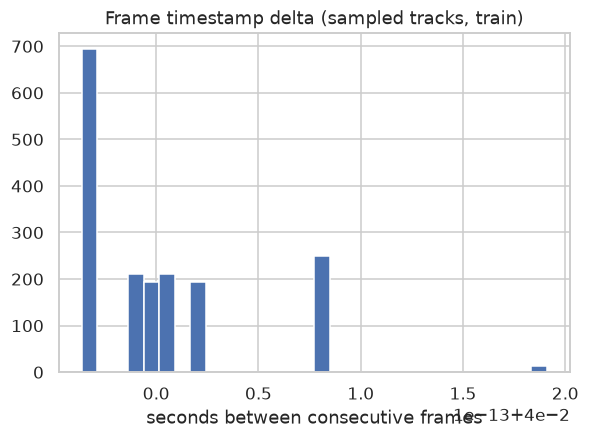

median delta: 0.0400s (~25.0 fps)


In [16]:
sample_entities = train_df["entity_id"].drop_duplicates().sample(20, random_state=0)
deltas = []
for eid in sample_entities:
    ts = train_df.loc[train_df["entity_id"] == eid, "frame_timestamp"].sort_values()
    deltas.extend(ts.diff().dropna().tolist())
    

plt.figure(figsize=(6, 4))
plt.hist(deltas, bins=30)
plt.title("Frame timestamp delta (sampled tracks, train)")
plt.xlabel("seconds between consecutive frames")
plt.show()

print(f"median delta: {np.median(deltas):.4f}s (~{1 / np.median(deltas):.1f} fps)")


### Tracks per video

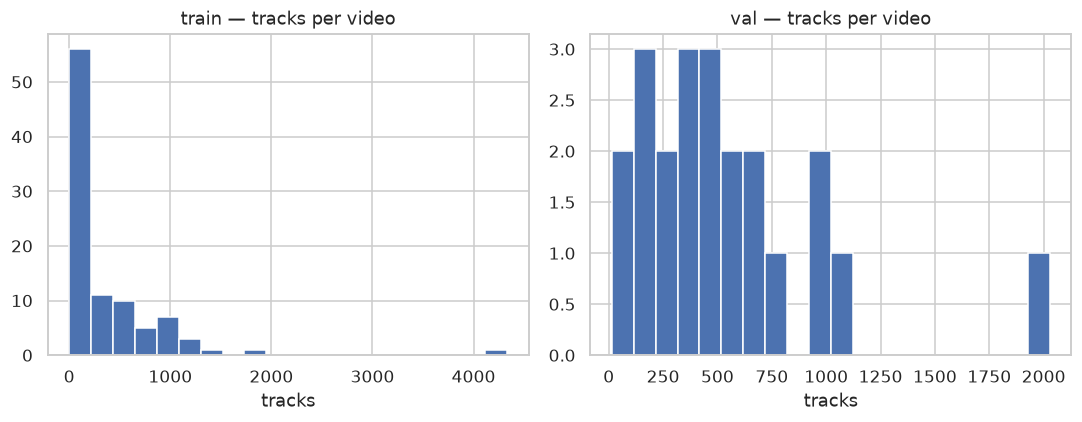

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split, df) in zip(axes, dfs.items()):
    tracks_per_video = df.groupby("video_id")["entity_id"].nunique()
    ax.hist(tracks_per_video, bins=20)
    ax.set_title(f"{split} — tracks per video")
    ax.set_xlabel("tracks")
fig.tight_layout()
plt.show()


## 5. Bounding Box Statistics

### Box width / height distribution (normalized coords)

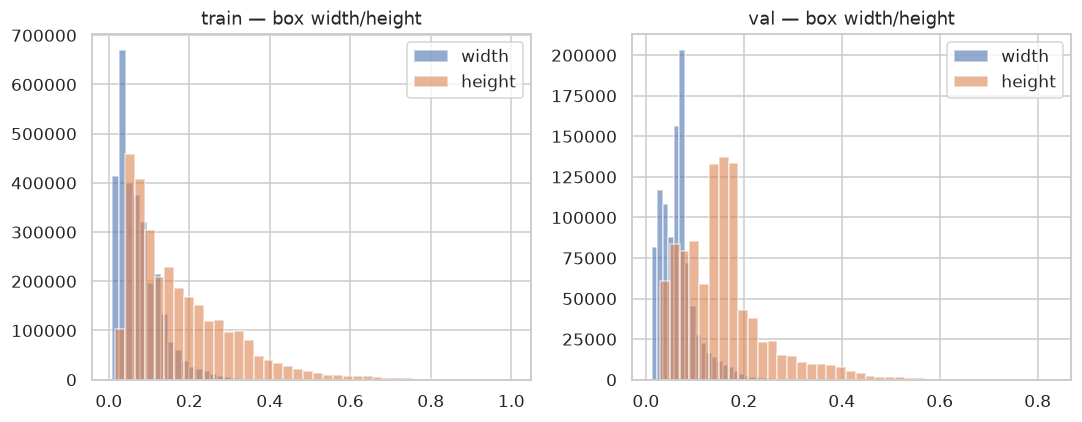

In [18]:
for split, df in dfs.items():
    df["box_w"] = df["entity_box_x2"] - df["entity_box_x1"]
    df["box_h"] = df["entity_box_y2"] - df["entity_box_y1"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split, df) in zip(axes, dfs.items()):
    ax.hist(df["box_w"], bins=40, alpha=0.6, label="width")
    ax.hist(df["box_h"], bins=40, alpha=0.6, label="height")
    ax.set_title(f"{split} — box width/height")
    ax.legend()
fig.tight_layout()
plt.show()


### Box aspect ratio and area

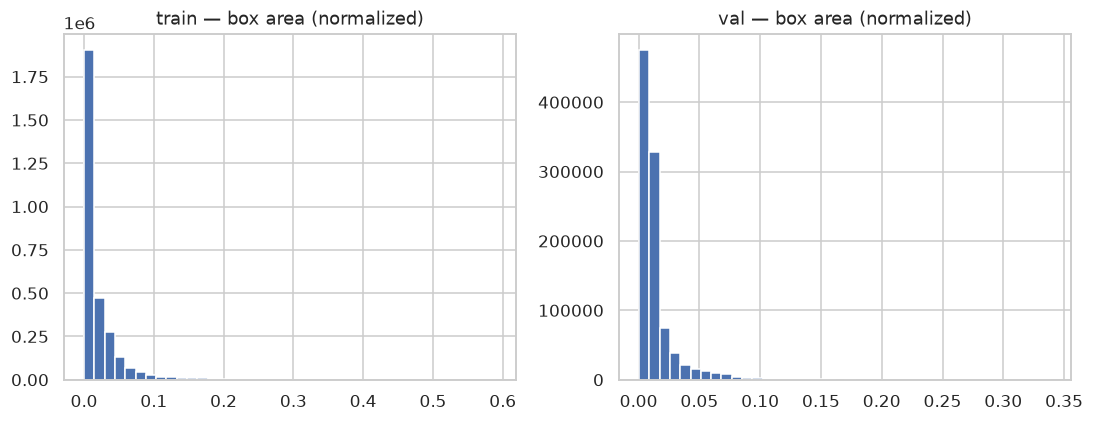

In [19]:
for split, df in dfs.items():
    df["box_aspect"] = df["box_w"] / df["box_h"]
    df["box_area"] = df["box_w"] * df["box_h"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split, df) in zip(axes, dfs.items()):
    ax.hist(df["box_area"], bins=40)
    ax.set_title(f"{split} — box area (normalized)")
fig.tight_layout()
plt.show()


### Box size by label (speaking vs not)

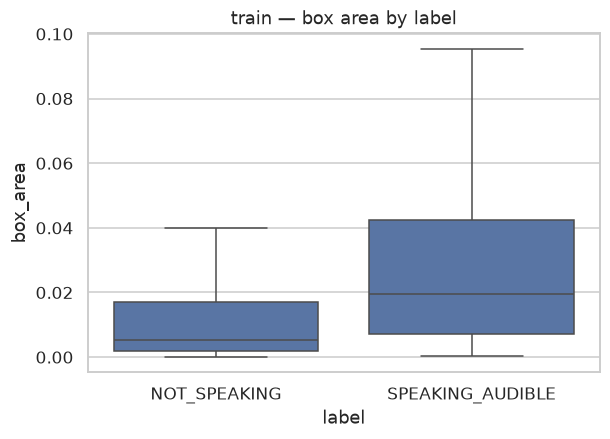

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=train_df, x="label", y="box_area", ax=ax, showfliers=False)
ax.set_title("train — box area by label")
plt.show()


## 6. Raw CSV Inspection

### Random sample rows

In [21]:
train_df.sample(15, random_state=0)

,video_id,frame_timestamp,entity_box_x1,entity_box_y1,entity_box_x2,entity_box_y2,label,entity_id,label_id,instance_id,box_w,box_h,box_aspect,box_area
2873602,x8mAJxsBeHc,98.32,0.300892,0.197199,0.377817,0.390975,NOT_SPEAKING,x8mAJxsBeHc:7,0,x8mAJxsBeHc:7:14,0.076925,0.193777,0.396978,0.014906
1195469,HEKmJiNxN5s,667.52,0.752158,0.376216,0.786112,0.450112,NOT_SPEAKING,HEKmJiNxN5s:656,0,HEKmJiNxN5s:656:0,0.033954,0.073896,0.459483,0.002509
2961245,xf2rLKMBytQ,533.12,0.797931,0.373211,0.850574,0.496271,NOT_SPEAKING,xf2rLKMBytQ:310,0,xf2rLKMBytQ:310:0,0.052643,0.123060,0.427784,0.006478
821247,DGyuHzlne6A,997.16,0.430240,0.166063,0.569422,0.484932,SPEAKING_AUDIBLE,DGyuHzlne6A:2258,1,DGyuHzlne6A:2258:0,0.139182,0.318869,0.436485,0.044381
1378538,ICISHNou9Zs,662.08,0.423478,0.168691,0.599453,0.582125,SPEAKING_AUDIBLE,ICISHNou9Zs:626,1,ICISHNou9Zs:626:0,0.175975,0.413434,0.425643,0.072754
564889,CMXykX5vaOQ,266.12,0.453281,0.094273,0.552939,0.341067,SPEAKING_AUDIBLE,CMXykX5vaOQ:349,1,CMXykX5vaOQ:349:0,0.099658,0.246794,0.403811,0.024595
2711591,vEzaIEXD9kU,197.08,0.374175,0.156656,0.499265,0.470322,SPEAKING_AUDIBLE,vEzaIEXD9kU:29,1,vEzaIEXD9kU:29:8,0.125089,0.313665,0.398799,0.039236
713738,DGyuHzlne6A,298.12,0.654330,0.357073,0.669053,0.391439,NOT_SPEAKING,DGyuHzlne6A:557,0,DGyuHzlne6A:557:0,0.014724,0.034367,0.428426,0.000506
1344504,ICISHNou9Zs,65.64,0.517663,0.173291,0.576054,0.310228,NOT_SPEAKING,ICISHNou9Zs:71,0,ICISHNou9Zs:71:0,0.058390,0.136937,0.426402,0.007996
1798859,OeHHBQ8uZas,76.16,0.592284,0.391538,0.665131,0.552088,NOT_SPEAKING,OeHHBQ8uZas:17,0,OeHHBQ8uZas:17:0,0.072847,0.160549,0.453736,0.011696


### Busiest and quietest videos by row count

In [22]:
row_counts = train_df["video_id"].value_counts()
print("Most rows:")
print(row_counts.head(5))
print("\nFewest rows:")
print(row_counts.tail(5))


Most rows:
video_id
DGyuHzlne6A    301819
Gb24lrewkTg    125524
CMXykX5vaOQ     99295
HEKmJiNxN5s     98756
9eJXc7jgHFI     96011
Name: count, dtype: int64

Fewest rows:
video_id
wiqfh7_chN0    3640
XOGwnVnlUpk    2711
r_5RDPgiWFY    1957
h7yBkFhjVtE    1602
RzXTe-QfWTw     915
Name: count, dtype: int64


## 7. Face Crop Image Inspection

### Helper to list a track's frame files on disk

In [23]:
def track_frame_paths(split: str, video_id: str, entity_id: str) -> list[Path]:
    track_dir = RAW_CLIPS_VIDEOS_DIR / split / video_id / entity_id
    return sorted(track_dir.glob("*.jpg"), key=lambda p: float(p.stem))


### CSV rows vs actual jpg files (sanity check)

In [24]:
rng = np.random.default_rng(0)
sample_ids = rng.choice(train_df["entity_id"].unique(), size=10, replace=False)

rows = []
for eid in sample_ids:
    vid = train_df.loc[train_df["entity_id"] == eid, "video_id"].iloc[0]
    csv_frames = int((train_df["entity_id"] == eid).sum())
    disk_frames = len(track_frame_paths("train", vid, eid))
    rows.append({"entity_id": eid, "csv_rows": csv_frames, "jpg_files": disk_frames, "match": csv_frames == disk_frames})

pd.DataFrame(rows)


,entity_id,csv_rows,jpg_files,match
0,r1_yw0LjGRo:207,71,71,True
1,jokAXdH2IQ0:280,25,25,True
2,SFa5_upNcHM:678,34,34,True
3,LHuDVf6FzI0:75,33,33,True
4,DGyuHzlne6A:1227,44,44,True
5,1xrAHh2fCk8:697,35,35,True
6,1hJn0KZ1cs8:136,41,41,True
7,DGyuHzlne6A:2626,95,95,True
8,9h-aW8JZmz8:27,75,75,True
9,2qmFwQbrVck:55,66,66,True


### Sample speaking vs not-speaking crops

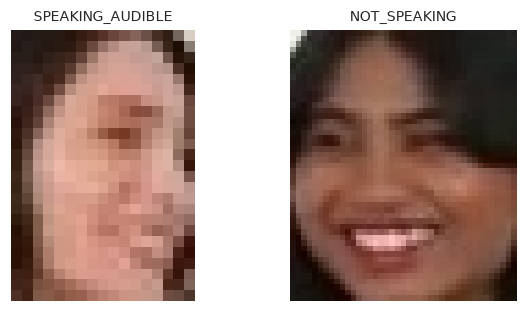

In [25]:
speaking_row = train_df[train_df["label_id"] == SPEAKING_LABEL_ID].sample(1, random_state=1).iloc[0]
not_speaking_row = train_df[train_df["label_id"] != SPEAKING_LABEL_ID].sample(1, random_state=1).iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, row in zip(axes, [speaking_row, not_speaking_row]):
    img_path = RAW_CLIPS_VIDEOS_DIR / "train" / row["video_id"] / row["entity_id"] / f'{row["frame_timestamp"]:.2f}.jpg'
    ax.imshow(Image.open(img_path))
    ax.set_title(row["label"], fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()


### Filmstrip of one track over time

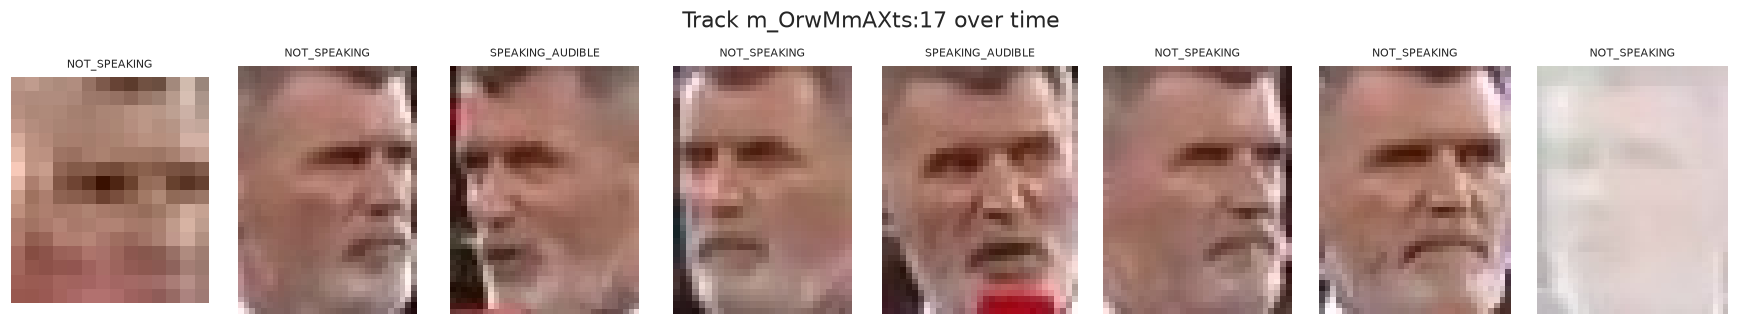

In [26]:
eid = train_df["entity_id"].value_counts().index[0]  # a long track
track = train_df[train_df["entity_id"] == eid].sort_values("frame_timestamp")
sample_rows = track.iloc[np.linspace(0, len(track) - 1, 8).astype(int)]

fig, axes = plt.subplots(1, len(sample_rows), figsize=(16, 3))
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = RAW_CLIPS_VIDEOS_DIR / "train" / row["video_id"] / row["entity_id"] / f'{row["frame_timestamp"]:.2f}.jpg'
    ax.imshow(Image.open(img_path))
    ax.set_title(row["label"], fontsize=7)
    ax.axis("off")
fig.suptitle(f"Track {eid} over time")
fig.tight_layout()
plt.show()


## 8. Summary

### Key numbers at a glance

In [27]:
summary = {
    "train rows": len(train_df),
    "val rows": len(val_df),
    "train videos": train_df["video_id"].nunique(),
    "val videos": val_df["video_id"].nunique(),
    "train tracks": train_df["entity_id"].nunique(),
    "val tracks": val_df["entity_id"].nunique(),
    "train speaking %": (train_df["label_id"] == SPEAKING_LABEL_ID).mean() * 100,
    "val speaking %": (val_df["label_id"] == SPEAKING_LABEL_ID).mean() * 100,
}
pd.Series(summary).to_frame("value")


,value
train rows,3.001883e+06
val rows,9.986440e+05
train videos,9.500000e+01
val videos,2.200000e+01
train tracks,3.679100e+04
val tracks,1.190200e+04
train speaking %,2.804267e+01
val speaking %,2.059853e+01
